# Advanced SVM Training for Employee Attrition

This notebook trains an advanced Support Vector Machine (SVM) model using preprocessed data from the `outputs` folder and reports complete evaluation metrics.

## What is included
- Data loading and integrity checks
- Standardized SVM pipeline
- Hyperparameter tuning with `GridSearchCV`
- Evaluation on test set (Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Confusion Matrix, Classification Report)
- ROC and Precision-Recall curves
- Artifact export (best model, metrics, predictions)

In [1]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

BASE_DIR = Path.cwd().resolve()
while BASE_DIR != BASE_DIR.parent and not (BASE_DIR / 'outputs').exists():
    BASE_DIR = BASE_DIR.parent

OUTPUTS_DIR = BASE_DIR / 'outputs'
if not OUTPUTS_DIR.exists():
    raise FileNotFoundError('Could not locate the outputs directory. Start the notebook from inside the project workspace.')

SVM_OUTPUT_DIR = OUTPUTS_DIR / 'SVM'
SVM_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Base directory: {BASE_DIR}')
print(f'Outputs directory: {OUTPUTS_DIR}')
print(f'SVM output directory: {SVM_OUTPUT_DIR}')

Base directory: D:\Campus\4 th year\ML\Assignment\employee-attrition-prediction
Outputs directory: D:\Campus\4 th year\ML\Assignment\employee-attrition-prediction\outputs
SVM output directory: D:\Campus\4 th year\ML\Assignment\employee-attrition-prediction\outputs\SVM


In [2]:
X_train_path = OUTPUTS_DIR / 'X_train_smote.csv'
X_test_path = OUTPUTS_DIR / 'X_test.csv'
y_train_path = OUTPUTS_DIR / 'y_train_smote.csv'
y_test_path = OUTPUTS_DIR / 'y_test.csv'

for p in [X_train_path, X_test_path, y_train_path, y_test_path]:
    if not p.exists():
        raise FileNotFoundError(f'Missing required file: {p}')

X_train = pd.read_csv(X_train_path)
X_test = pd.read_csv(X_test_path)
y_train_df = pd.read_csv(y_train_path)
y_test_df = pd.read_csv(y_test_path)

display(X_train.head(3))
display(y_train_df.head(3))

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train shape: {y_train_df.shape}')
print(f'y_test shape:  {y_test_df.shape}')

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,47,1225,2,4,2,47,4,4,2,15972,...,False,True,False,False,False,False,False,False,False,False
1,22,594,2,1,3,100,3,1,4,2523,...,True,False,False,False,False,False,False,True,False,False
2,46,406,3,1,1,52,3,4,3,17465,...,False,True,False,False,False,False,False,True,False,False


,Attrition
0,0
1,0
2,0


X_train shape: (1972, 44)
X_test shape:  (294, 44)
y_train shape: (1972, 1)
y_test shape:  (294, 1)


In [3]:
target_col = 'Attrition'

if target_col in y_train_df.columns:
    y_train = y_train_df[target_col].copy()
else:
    y_train = y_train_df.iloc[:, 0].copy()

if target_col in y_test_df.columns:
    y_test = y_test_df[target_col].copy()
else:
    y_test = y_test_df.iloc[:, 0].copy()

y_train = pd.to_numeric(y_train, errors='coerce')
y_test = pd.to_numeric(y_test, errors='coerce')

if y_train.isna().any() or y_test.isna().any():
    raise ValueError('Target contains non-numeric values that could not be converted.')

y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Ensure all feature columns in test exist and align exactly to training schema
missing_in_test = set(X_train.columns) - set(X_test.columns)
extra_in_test = set(X_test.columns) - set(X_train.columns)
if missing_in_test:
    raise ValueError(f'Test set missing columns: {missing_in_test}')
if extra_in_test:
    print(f'Warning: extra test columns found and will be dropped: {extra_in_test}')

X_test = X_test[X_train.columns]

print('Class distribution in y_train:')
print(y_train.value_counts(normalize=True).sort_index())
print('\nClass distribution in y_test:')
print(y_test.value_counts(normalize=True).sort_index())

Class distribution in y_train:
Attrition
0    0.5
1    0.5
Name: proportion, dtype: float64

Class distribution in y_test:
Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64


In [4]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, random_state=42))
])

param_grid = {
    'svm__kernel': ['rbf', 'linear', 'poly'],
    'svm__C': [0.1, 1, 10, 50],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1],
    'svm__degree': [2, 3],
    'svm__class_weight': [None, 'balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print('Best CV F1 score:', round(grid_search.best_score_, 4))
print('Best parameters:')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')

Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best CV F1 score: 0.9125
Best parameters:
  svm__C: 1
  svm__class_weight: None
  svm__degree: 2
  svm__gamma: 0.01
  svm__kernel: rbf


Test Set Metrics:
  accuracy: 0.8503
 precision: 0.5600
    recall: 0.2979
  f1_score: 0.3889
   roc_auc: 0.7194
    pr_auc: 0.4762

Classification Report:
              precision    recall  f1-score   support

           0     0.8773    0.9555    0.9147       247
           1     0.5600    0.2979    0.3889        47

    accuracy                         0.8503       294
   macro avg     0.7187    0.6267    0.6518       294
weighted avg     0.8266    0.8503    0.8307       294



,Pred 0,Pred 1
Actual 0,236,11
Actual 1,33,14


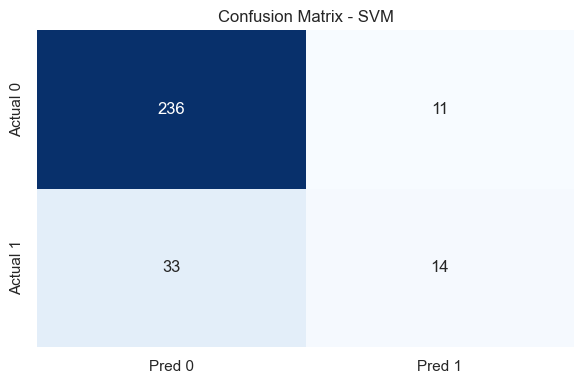

In [5]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1_score': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba),
    'pr_auc': average_precision_score(y_test, y_proba)
}

print('Test Set Metrics:')
for name, value in metrics.items():
    print(f'{name:>10}: {value:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Pred 0', 'Pred 1'])
display(cm_df)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - SVM')
plt.tight_layout()
plt.show()

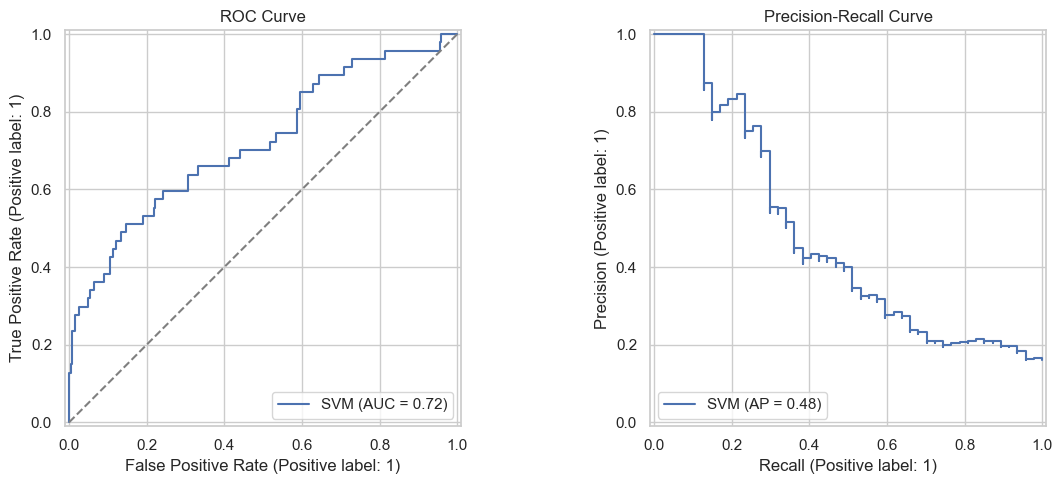

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0], name='SVM')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1], name='SVM')
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

In [7]:
cv_scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=cv_scoring,
    n_jobs=-1
)

cv_summary = pd.DataFrame({
    metric: [cv_results[f'test_{metric}'].mean(), cv_results[f'test_{metric}'].std()]
    for metric in cv_scoring
}, index=['mean', 'std']).T

print('Cross-validation summary on training data:')
display(cv_summary.round(4))

Cross-validation summary on training data:


,mean,std
accuracy,0.9173,0.0156
precision,0.9694,0.0189
recall,0.8621,0.0196
f1,0.9125,0.0165
roc_auc,0.9615,0.0113


In [8]:
model_path = SVM_OUTPUT_DIR / 'best_svm_model.joblib'
metrics_path = SVM_OUTPUT_DIR / 'svm_test_metrics.csv'
predictions_path = SVM_OUTPUT_DIR / 'svm_test_predictions.csv'
cv_path = SVM_OUTPUT_DIR / 'svm_cv_summary.csv'

joblib.dump(best_model, model_path)

metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(metrics_path, index=False)

pred_df = pd.DataFrame({
    'y_true': y_test.values,
    'y_pred': y_pred,
    'y_proba': y_proba
})
pred_df.to_csv(predictions_path, index=False)

cv_summary.to_csv(cv_path)

print('Saved artifacts:')
print(f'- Model: {model_path}')
print(f'- Test metrics: {metrics_path}')
print(f'- Test predictions: {predictions_path}')
print(f'- CV summary: {cv_path}')

Saved artifacts:
- Model: D:\Campus\4 th year\ML\Assignment\employee-attrition-prediction\outputs\SVM\best_svm_model.joblib
- Test metrics: D:\Campus\4 th year\ML\Assignment\employee-attrition-prediction\outputs\SVM\svm_test_metrics.csv
- Test predictions: D:\Campus\4 th year\ML\Assignment\employee-attrition-prediction\outputs\SVM\svm_test_predictions.csv
- CV summary: D:\Campus\4 th year\ML\Assignment\employee-attrition-prediction\outputs\SVM\svm_cv_summary.csv


## Notes
- If runtime is high, reduce the grid size in `param_grid`.
- You can switch optimization target from `f1` to `roc_auc` by changing `scoring` in `GridSearchCV`.
- If your business prefers fewer false negatives, tune decision threshold using `y_proba`.